# Установка бибилиотек

In [ ]:
!pip install opencv-python numpy tqdm pillow albumentations

In [ ]:
import os
import shutil
import cv2
import random
from tqdm import tqdm
import random
import zipfile
import numpy as np
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# Распаковка ZIP

Определяем пути:
* `ZIP_FILE = "chandeliers.zip"` – имя архива с изображениями.
* `EXTRACT_DIR = "raw_images"` – папка, куда будет распакован архив.
* `DATASET_DIR = "chandeliers_dataset"` – итоговая структура датасета.

Распаковывает архив `chandeliers.zip` в папку `raw_images`.

In [ ]:
ZIP_FILE = "chandeliers.zip"

In [ ]:
EXTRACT_DIR = "raw_images"

In [ ]:
DATASET_DIR = "chandeliers_dataset"

Создаём структуры папок:
- Определяем категории люстр `(classic_chandelier, modern_chandelier, retro_chandelier)`.
- Определяем типы данных `(Train, Validate, Test)`.
- Для каждой категории в каждом типе создаются папки в `chandeliers_dataset`.

In [ ]:
CATEGORIES = ["classic_chandlier", "moder_chandelier", "retro_chandlier"]

In [ ]:
SPLIT = ["Train", "Test", "Validate"]

Перейдём к написанию кода.

Функция `split_dataset()` - это разбивка данных на `Train/Validate/Test`. Она получает список всех изображений в категории, перемешивает их случайным образом.

Разделяет следующим образом:
- 70% → `Train`
- 20% → `Validate`
- 10% → `Test`

И копирует изображения в соответствующие папки.

Функция `preprocess_images()` - это предобработка изображений (изменение размера). Она загружает изображение из PIL.Image (конвертируя в RGB), изменяет размер на (300, 300) и сохраняет обратно.

Функция `augment_images()` использует albumentations для создания новых вариантов изображений.
Здесь применяются такие трансформации, как:
* Изменение контраста и яркости (RandomBrightnessContrast)
* Горизонтальное отражение (HorizontalFlip)
* Сдвиг, масштабирование, поворот (ShiftScaleRotate)
* Гауссово размытие (GaussianBlur)

Функция загружает изображения с помощью OpenCV (`cv2.imread()`), применяет вышеуказанные преобразования. Создаёт 5 новых версий каждого изображения (`num_augmented=5`) и сохраняет аугментированные файлы в `Train/`.

In [ ]:
# --- Распаковка архива ---
ZIP_FILE = "/content/chandeliers_dataset.zip"  # Имя архива
EXTRACT_DIR = "raw_images"  # Куда распаковать
DATASET_DIR = "chandeliers_dataset"  # Итоговая структура папок

CATEGORIES = ["classic_chandelier", "modern_chandelier", "retro_chandelier"]
SPLITS = ["Train", "Validate", "Test"]

# Распаковываем ZIP
if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR)

print(f"Распаковка архива {ZIP_FILE}...")
with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Архив успешно распакован!")

# --- Создание папок ---
for split in SPLITS:
    for category in CATEGORIES:
        os.makedirs(os.path.join(DATASET_DIR, split, category), exist_ok=True)

# --- Разбивка датасета на Train, Validate, Test ---
def split_dataset(source_folder, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1):
    images = [img for img in os.listdir(source_folder) if img.endswith(('.jpg', '.png', '.jpeg'))]
    random.shuffle(images)

    train_split = int(len(images) * train_ratio)
    val_split = int(len(images) * (train_ratio + val_ratio))

    return images[:train_split], images[train_split:val_split], images[val_split:]

# Распределяем изображения
for category in CATEGORIES:
    source_folder = os.path.join(EXTRACT_DIR, category)

    if not os.path.exists(source_folder):
        print(f"⚠️ Папка {source_folder} не найдена, пропускаем.")
        continue

    train_images, val_images, test_images = split_dataset(source_folder)

    for img_name in train_images:
        shutil.copy(os.path.join(source_folder, img_name), os.path.join(DATASET_DIR, "Train", category, img_name))
    for img_name in val_images:
        shutil.copy(os.path.join(source_folder, img_name), os.path.join(DATASET_DIR, "Validate", category, img_name))
    for img_name in test_images:
        shutil.copy(os.path.join(source_folder, img_name), os.path.join(DATASET_DIR, "Test", category, img_name))

print("✅ Разбивка завершена!")

# --- Предобработка изображений ---
def preprocess_images(folder, image_size=(300, 300)):
    for category in CATEGORIES:
        category_folder = os.path.join(folder, category)
        if not os.path.exists(category_folder):
            continue

        for img_name in tqdm(os.listdir(category_folder), desc=f"Обработка {category_folder}"):
            img_path = os.path.join(category_folder, img_name)
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize(image_size, Image.ANTIALIAS)
                img.save(img_path, "JPEG")
            except Exception as e:
                print(f"Ошибка обработки {img_name}: {e}")

print("📏 Обрабатываем изображения...")
for split in SPLITS:
    preprocess_images(os.path.join(DATASET_DIR, split))

print("✅ Предобработка завершена!")

# --- Аугментация Train ---
augmentations = A.Compose([
    A.RandomBrightnessContrast(p=0.2),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.GaussianBlur(p=0.2),
    ToTensorV2()
])

def augment_images(source_folder, num_augmented=5):
    for category in CATEGORIES:
        category_folder = os.path.join(source_folder, category)
        if not os.path.exists(category_folder):
            continue

        for img_name in tqdm(os.listdir(category_folder), desc=f"Аугментация {category_folder}"):
            img_path = os.path.join(category_folder, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            for i in range(num_augmented):
                augmented = augmentations(image=img)["image"]
                aug_img_name = f"aug_{i}_{img_name}"
                aug_img_path = os.path.join(category_folder, aug_img_name)
                cv2.imwrite(aug_img_path, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))

print("🎨 Аугментируем изображения...")
augment_images(os.path.join(DATASET_DIR, "Train"))

print("✅ Аугментация завершена!")

Распаковка архива /content/chandeliers_dataset.zip...
Архив успешно распакован!
⚠️ Папка raw_images/classic_chandelier не найдена, пропускаем.
⚠️ Папка raw_images/modern_chandelier не найдена, пропускаем.
⚠️ Папка raw_images/retro_chandelier не найдена, пропускаем.
✅ Разбивка завершена!
📏 Обрабатываем изображения...


Обработка chandeliers_dataset/Train/classic_chandelier: 0it [00:00, ?it/s]
Обработка chandeliers_dataset/Train/modern_chandelier: 0it [00:00, ?it/s]
Обработка chandeliers_dataset/Train/retro_chandelier: 0it [00:00, ?it/s]
Обработка chandeliers_dataset/Validate/classic_chandelier: 0it [00:00, ?it/s]
Обработка chandeliers_dataset/Validate/modern_chandelier: 0it [00:00, ?it/s]
Обработка chandeliers_dataset/Validate/retro_chandelier: 0it [00:00, ?it/s]
Обработка chandeliers_dataset/Test/classic_chandelier: 0it [00:00, ?it/s]
Обработка chandeliers_dataset/Test/modern_chandelier: 0it [00:00, ?it/s]
Обработка chandeliers_dataset/Test/retro_chandelier: 0it [00:00, ?it/s]
/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:58: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


✅ Предобработка завершена!
🎨 Аугментируем изображения...


Аугментация chandeliers_dataset/Train/classic_chandelier: 0it [00:00, ?it/s]
Аугментация chandeliers_dataset/Train/modern_chandelier: 0it [00:00, ?it/s]
Аугментация chandeliers_dataset/Train/retro_chandelier: 0it [00:00, ?it/s]

✅ Аугментация завершена!


Возникали ошибки связанные с путём и размера изображений. Чем отличается следующий код от предыдущего:

1. Исправление пути к файлам:
- В первом коде архив распаковывался в raw_images, но в нем была некорректная структура (`/content/raw_images/content/content/chandeliers`).
- Во втором коде добавлена логика исправления структуры: файлы перемещаются в raw_images, а ненужные вложенные папки удаляются.

2. Исправление метода изменения размера изображений:

В первом коде использовался устаревший `Image.ANTIALIAS`, который удален в новых версиях Pillow.

Исправлено на:
`img = img.resize(target_size, Image.Resampling.LANCZOS)`

Теперь используется `Image.Resampling.LANCZOS`, что соответствует современной версии Pillow.

3. Улучшение предобработки изображений:
теперь в случае отсутствия папки с изображениями код не просто пропускает её, а выводит предупреждение:

```
if not os.path.exists(category_folder):
    print(f"⚠️ Папка {category_folder} не найдена, пропускаем.")
    continue
```

И добавлен явный вызов `.convert("RGB")`, чтобы избежать ошибок с разными цветовыми форматами.



In [ ]:
# Где сейчас файлы (неправильный путь)
WRONG_PATH = "/content/raw_images/content/content/chandeliers"

# Куда их перенести (правильный путь)
CORRECT_PATH = "/content/raw_images"

CATEGORIES = {
    "classic": "classic_chandelier",
    "modern": "modern_chandelier",
    "retro": "retro_chandelier"
}

# Проверяем, существует ли папка с неправильной структурой
if os.path.exists(WRONG_PATH):
    for old_folder, new_folder in CATEGORIES.items():
        old_path = os.path.join(WRONG_PATH, old_folder)
        new_path = os.path.join(CORRECT_PATH, new_folder)

        if os.path.exists(old_path):
            # Создаем папку, если ее нет
            os.makedirs(new_path, exist_ok=True)

            # Перемещаем файлы
            for file in os.listdir(old_path):
                shutil.move(os.path.join(old_path, file), os.path.join(new_path, file))

            print(f"✅ Файлы из {old_path} перенесены в {new_path}")

    # Удаляем пустые папки
    shutil.rmtree("/content/raw_images/content")
    print("🗑 Удалены пустые папки /content/raw_images/content")

else:
    print("❌ Ошибка! Папка с неправильной структурой не найдена.")

print("✅ Структура исправлена! Теперь можно запускать разбиение Train/Validate/Test.")

❌ Ошибка! Папка с неправильной структурой не найдена.
✅ Структура исправлена! Теперь можно запускать разбиение Train/Validate/Test.


In [ ]:
# --- Константы ---
DATASET_DIR = "chandeliers_dataset"
CATEGORIES = ["classic_chandelier", "modern_chandelier", "retro_chandelier"]

# --- Функция предобработки изображений --
def preprocess_images(source_folder, target_size=(300, 300)):
    for category in CATEGORIES:
        category_folder = os.path.join(source_folder, category)
        if not os.path.exists(category_folder):
            print(f"⚠️ Папка {category_folder} не найдена, пропускаем.")
            continue

        print(f"📦 Обрабатываем {category_folder}...")
        for img_name in tqdm(os.listdir(category_folder)):
            img_path = os.path.join(category_folder, img_name)
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize(target_size, Image.Resampling.LANCZOS)  # Исправлено

                img.save(img_path)  # Сохраняем обработанное изображение
            except Exception as e:
                print(f"❌ Ошибка обработки {img_name}: {e}")

    print("✅ Предобработка завершена!")

# --- Функция аугментации изображений ---
def augment_images(source_folder, num_augmented=5):
    for category in CATEGORIES:
        category_folder = os.path.join(source_folder, category)
        if not os.path.exists(category_folder):
            print(f"⚠️ Папка {category_folder} не найдена, пропускаем.")
            continue

        print(f"🎨 Аугментация {category_folder}...")
        images = [img for img in os.listdir(category_folder) if img.endswith(('.jpg', '.png', '.jpeg'))]

        for img_name in tqdm(images):
            img_path = os.path.join(category_folder, img_name)
            try:
                img = Image.open(img_path).convert("RGB")

                for i in range(num_augmented):
                    aug_img = img

                    # Рандомные преобразования
                    if random.random() > 0.5:
                        aug_img = aug_img.transpose(Image.FLIP_LEFT_RIGHT)
                    if random.random() > 0.5:
                        enhancer = ImageEnhance.Brightness(aug_img)
                        aug_img = enhancer.enhance(random.uniform(0.7, 1.3))
                    if random.random() > 0.5:
                        enhancer = ImageEnhance.Contrast(aug_img)
                        aug_img = enhancer.enhance(random.uniform(0.8, 1.2))

                    # Преобразование в NumPy для OpenCV
                    aug_img_np = np.array(aug_img)

                    # Сохранение через OpenCV
                    aug_img_name = f"aug_{i}_{img_name}"
                    aug_img_path = os.path.join(category_folder, aug_img_name)
                    cv2.imwrite(aug_img_path, cv2.cvtColor(aug_img_np, cv2.COLOR_RGB2BGR))

            except Exception as e:
                print(f"❌ Ошибка обработки {img_name}: {e}")

    print("✅ Аугментация завершена!")

# --- Запуск предобработки и аугментации ---
preprocess_images(os.path.join(DATASET_DIR, "Train"))
augment_images(os.path.join(DATASET_DIR, "Train"))

📦 Обрабатываем chandeliers_dataset/Train/classic_chandelier...


0it [00:00, ?it/s]


📦 Обрабатываем chandeliers_dataset/Train/modern_chandelier...


0it [00:00, ?it/s]


📦 Обрабатываем chandeliers_dataset/Train/retro_chandelier...


...

🎨 Аугментация chandeliers_dataset/Train/modern_chandelier...


0it [00:00, ?it/s]


🎨 Аугментация chandeliers_dataset/Train/retro_chandelier...


0it [00:00, ?it/s]

✅ Аугментация завершена!


# Обучение модели на TensorFlow/Keras

In [ ]:
!pip install tensorflow tensorflow-addons

Загружаем основные библиотеки, включая TensorFlow, Keras, OpenCV, PIL и sklearn (для подсчёта весов классов).

In [ ]:
# Основные библиотеки
import os
import shutil
import zipfile
import random
import numpy as np
import cv2
from tqdm import tqdm
from PIL import Image, ImageEnhance

# TensorFlow и Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3

# Сбалансировка классов
from sklearn.utils.class_weight import compute_class_weight

Повторяем подготовку данных, алгоритм идентичен, что и в начале.

In [ ]:
# --- Константы ---
ZIP_FILE = "chandeliers_dataset.zip"
EXTRACT_DIR = "raw_images"
DATASET_DIR = "chandeliers_dataset"
CATEGORIES = ["classic_chandelier", "modern_chandelier", "retro_chandelier"]
SPLITS = ["Train", "Validate", "Test"]

# Распаковка ZIP
if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR)
with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("✅ Архив успешно распакован!")

NameError: name 'os' is not defined

In [ ]:
# --- Создание папок ---
for split in SPLITS:
    for category in CATEGORIES:
        os.makedirs(os.path.join(DATASET_DIR, split, category), exist_ok=True)

# --- Функция разбиения данных ---
def split_dataset(source_folder, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1):
    images = [img for img in os.listdir(source_folder) if img.lower().endswith(('.jpg', '.png', '.jpeg'))]
    random.shuffle(images)
    train_split = int(len(images) * train_ratio)
    val_split = int(len(images) * (train_ratio + val_ratio))
    return images[:train_split], images[train_split:val_split], images[val_split:]

# --- Распределение изображений по папкам ---
for category in CATEGORIES:
    source_folder = os.path.join(EXTRACT_DIR, category)
    if not os.path.exists(source_folder):
        print(f"⚠️ Папка {source_folder} не найдена, пропускаем.")
        continue
    train_images, val_images, test_images = split_dataset(source_folder)
    for img_name in train_images:
        shutil.copy(os.path.join(source_folder, img_name), os.path.join(DATASET_DIR, "Train", category, img_name))
    for img_name in val_images:
        shutil.copy(os.path.join(source_folder, img_name), os.path.join(DATASET_DIR, "Validate", category, img_name))
    for img_name in test_images:
        shutil.copy(os.path.join(source_folder, img_name), os.path.join(DATASET_DIR, "Test", category, img_name))

print("✅ Датасет успешно разделён на Train/Validate/Test!")

✅ Архив успешно распакован!
✅ Датасет успешно разделён на Train/Validate/Test!


Устанавливает размер изображений $300$ x $300$ и размер батча $32$.

Делаем аугментацию данных: повороты, сдвиги, изменения масштаба.


```
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
```



In [ ]:
# --- Генераторы изображений ---
IMAGE_SIZE = (300, 300)  # Увеличиваем размер для лучшего распознавания деталей
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

Found 0 images belonging to 3 classes.
Found 0 images belonging to 3 classes.
Found 0 images belonging to 3 classes.


NameError: name 'compute_class_weight' is not defined

Валидационные и тестовые изображения только нормализуются.

In [ ]:
# --- Генераторы данных ---
train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, "Train"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, "Validate"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, "Test"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Чтобы устранить дисбаланс классов, необходимо определить веса классов, которые будут обратно пропорциональны их частоте в обучающем наборе данных. Эти веса преобразуются в словарь и становятся доступными для использования при обучении модели.

In [ ]:
# --- Сбалансировка классов ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("⚖️ Class Weights:", class_weights)

Что дальше делаем:

1. Создаём базовую модель.

Используем предварительно обученную модель `EfficientNetB3` с весами `ImageNet`. Удаляем верхний классификационный слой `(include_top=False)` и задается размер входного изображения ($300$ x $300$ пикселей, $3$ канала).

2. Замораживаем слои базовой модели.

Все слои `EfficientNetB3` замораживаются (`layer.trainable = False`). Это делается для того, чтобы на первом этапе обучения обучать только новые добавленные слои, а не переобучать всю `EfficientNetB3`, что может быть ресурсозатратно и привести к переобучению на небольшом наборе данных.

3. Добавляем новые слои.

К выходу замороженной базовой модели добавляем следующие слои:
  * Слой Flatten - преобразует многомерные данные в одномерный вектор.
  * Два полносвязных слоя, Dense, с активацией ReLU и Dropout (для регуляризации).
  * Выходной слой Dense с активацией Softmax. Количество нейронов в выходном слое соответствует количеству классов (`len(CATEGORIES)`).

4. Создаём модель.

Создаём экземпляр Model, который соединяет вход базовой модели с выходом новых слоев.

5. Компиляция модели.

Модель компилируется с использованием оптимизатора Adam (с низкой скоростью обучения 0.0001), функции потерь `categorical cross-entropy` и метрики `accuracy`.

6. Вывод структуры модели.

`model.summary()` выводит сводную информацию о структуре модели (слои, параметры и т.д.).

7. Настройка колбэков:
   - `EarlyStopping`: останавливает обучение, если значение `val_loss` не улучшается в течение $5$ эпох, и восстанавливает веса модели с наилучшим качеством.
   - `ReduceLROnPlateau`: уменьшает скорость обучения (`learning_rate`) в $5$ раз, если `val_loss` не улучшается в течение $3$ эпох, но не ниже $1e-6$.

8. Первый этап обучения:
   - Модель обучается на данных из `train_generator` с валидацией на `val_generator`.
   - Количество эпох: $30$.
   - Учитываются веса классов (`class_weights`) для борьбы с дисбалансом классов.

9. Разморозка последних слоёв:
   - Последние $30$ слоёв базовой модели (`base_model`) делаются обучаемыми для дообучения.

10. Компиляция модели:
   - Модель компилируется с оптимизатором Adam и меньшей скоростью обучения ($0.00001$), чтобы точнее настроить веса размороженных слоёв.

11. Второй этап обучения (дообучение):
   - Модель дообучается ещё $15$ эпох с теми же колбэками и учётом весов классов.

In [ ]:
# --- Создание модели ---
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(300, 300, 3))

# Заморозим базовые слои для первого этапа обучения
for layer in base_model.layers:
    layer.trainable = False

# Добавляем дополнительные слои
x = Flatten()(base_model.output)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
output = Dense(len(CATEGORIES), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# --- Компиляция модели ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 300, 300, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_2 (Rescaling)   │ (None, 300, 300, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_1           │ (None, 300, 300, 3)    │              7 │ rescaling_2[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_3 (Rescaling)   │ (None, 300, 300, 3)    │              0 │ normalization_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 301, 301, 3)    │              0 │ rescaling_3[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 150, 150, 40)   │          1,080 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 150, 150, 40)   │            160 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 150, 150, 40)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 150, 150, 40)   │            360 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 150, 150, 40)   │            160 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 150, 150, 40)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 40)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 40)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 10)       │            410 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 168,597,298 (643.15 MB)

 Trainable params: 157,813,763 (602.01 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [ ]:
# --- Колбэки ---
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# --- Обучение ---
EPOCHS = 30
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

# --- Разморозка последних слоёв для дообучения ---
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- Дообучение ---
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 200s 20s/step - accuracy: 0.2978 - loss: 5.2964 - val_accuracy: 0.1852 - val_loss: 4.7938 - learning_rate: 1.0000e-04
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 157s 18s/step - accuracy: 0.2925 - loss: 4.2357 - val_accuracy: 0.1852 - val_loss: 2.7332 - learning_rate: 1.0000e-04
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 165s 19s/step - accuracy: 0.3050 - loss: 3.5277 - val_accuracy: 0.1852 - val_loss: 1.9446 - learning_rate: 1.0000e-04
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 160s 18s/step - accuracy: 0.3788 - loss: 2.9232 - val_accuracy: 0.1852 - val_loss: 2.0548 - learning_rate: 1.0000e-04
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 155s 17s/step - accuracy: 0.3608 - loss: 2.2907 - val_accuracy: 0.2500 - val_loss: 2.5710 - learning_rate: 1.0000e-04
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 156s 17s/step - accuracy: 0.2926 - loss: 2.6987 - val_accuracy: 0.1852 - val_loss: 1.1714 - learning_rate: 1.0000e-04
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 168s 19s/step - accuracy: 0.3363 - loss:

In [ ]:
# --- Оценка точности ---
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"✅ Точность на тестовых данных: {test_accuracy * 100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 25s 9s/step - accuracy: 0.7097 - loss: 0.8354
✅ Точность на тестовых данных: 56.45%


In [ ]:
# --- Сохранение модели ---
model.save("chandeliers_classifier_efficientnetB3.h5")
print("💾 Модель успешно сохранена!")

💾 Модель успешно сохранена!


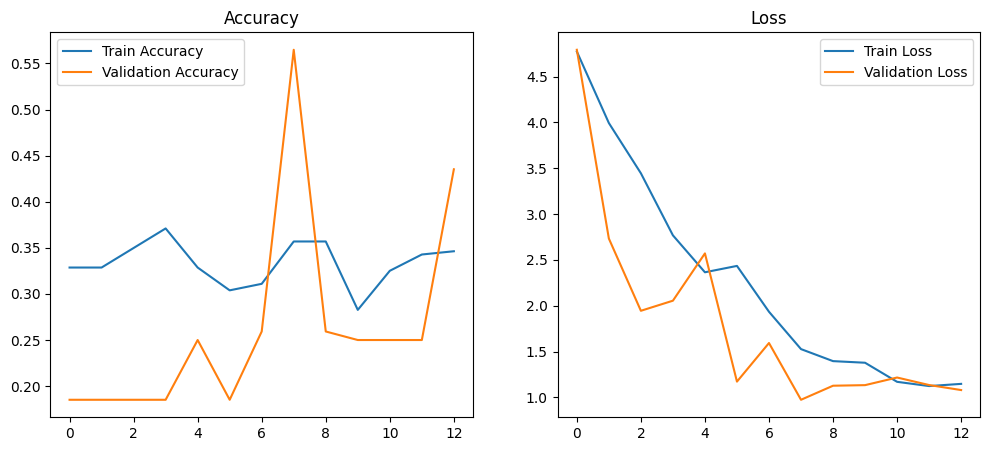

In [ ]:
import matplotlib.pyplot as plt

# --- Графики точности и ошибки ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

Внесём изменения в код:
1. Модель и архитектура:
   - Старый код использует `EfficientNetB3`, новый — более крупную модель `EfficientNetB4`.
   - В новом коде вместо `Flatten` используется `GlobalAveragePooling2D` для улучшения обобщения модели.

2. Размер изображений:
   - В старом коде размер изображений равен ($300$, $300$), во новом увеличен до ($380$, $380$), что соответствует входному размеру `EfficientNetB4`.

3. Аугментация данных:
   - В новом коде аугментации данных упрощены (например, уменьшены диапазоны поворотов, сдвига и добавлен параметр `brightness_range`) для лучшей генерализации модели.

4. Количество слоёв при разморозке:
   - В старом коде размораживаются только последние $30$ слоёв базовой модели на этапе дообучения.
   - Во новом коде сначала заморожены все слои, кроме последних $50$, а затем выполняется полная разморозка всех слоёв для финального дообучения.

5. Скорость обучения:
   - На этапе дообучения старый код использует скорость обучения $0.00001$, а новый — значительно меньшую скорость $1e-6$ для точной настройки всей модели.

6. Дополнительные слои:
   - Новый код добавляет больше слоёв `BatchNormalization` и применяет два уровня `Dropout` (по $0.4$) для улучшения регуляризации.

7. Оценка и сохранение модели:
   - Новый код включает дополнительный этап оценки модели на тестовых данных (`model.evaluate`) и сохраняет обученную модель в файл (`chandeliers_classifier_efficientnetB4_75.h5`).

In [ ]:
import os
import shutil
import zipfile
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image, ImageEnhance

# TensorFlow и Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4

# Сбалансировка классов
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# --- Параметры ---
IMAGE_SIZE = (380, 380)
BATCH_SIZE = 32
EPOCHS = 50
FINE_TUNE_EPOCHS = 30

# --- Генераторы изображений (уменьшены аугментации для лучшей генерализации) ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# --- Генераторы данных ---
train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, "Train"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, "Validate"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, "Test"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Сбалансировка классов ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("⚖️ Class Weights:", class_weights)

# --- Создание модели ---
base_model = EfficientNetB4(weights='imagenet', include_top=False, input_shape=(380, 380, 3))

# Размораживаем больше слоёв
for layer in base_model.layers[:-50]:
    layer.trainable = False

# GlobalAveragePooling2D вместо Flatten для лучшей генерализации
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(len(CATEGORIES), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# --- Компиляция модели ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# --- Колбэки ---
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# --- Обучение ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

# --- Дообучение с полной разморозкой ---
for layer in base_model.layers:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

# --- Оценка точности ---
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"✅ Точность на тестовых данных: {test_accuracy * 100:.2f}%")

# --- Сохранение модели ---
model.save("chandeliers_classifier_efficientnetB4_75.h5")
print("💾 Модель успешно сохранена!")

Found 320 images belonging to 3 classes.
Found 255 images belonging to 3 classes.
Found 179 images belonging to 3 classes.
⚖️ Class Weights: {0: 0.5925925925925926, 1: 1.350210970464135, 2: 1.7486338797814207}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 380, 380, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 380, 380, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 380, 380, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 380, 380, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 381, 381, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 190, 190, 48)   │          1,296 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 190, 190, 48)   │            192 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 190, 190, 48)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 190, 190, 48)   │            432 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 190, 190, 48)   │            192 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 190, 190, 48)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 48)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 48)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 12)       │            588 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_expand    

 Total params: 20,042,338 (76.46 MB)

 Trainable params: 9,245,627 (35.27 MB)

 Non-trainable params: 10,796,711 (41.19 MB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 301s 28s/step - accuracy: 0.3173 - loss: 1.9927 - val_accuracy: 0.2392 - val_loss: 1.1241 - learning_rate: 1.0000e-04
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 318s 28s/step - accuracy: 0.3260 - loss: 1.9394 - val_accuracy: 0.5647 - val_loss: 1.0745 - learning_rate: 1.0000e-04
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 355s 32s/step - accuracy: 0.2915 - loss: 1.9246 - val_accuracy: 0.5686 - val_loss: 1.0666 - learning_rate: 1.0000e-04
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 277s 27s/step - accuracy: 0.2955 - loss: 1.9633 - val_accuracy: 0.5686 - val_loss: 1.0600 - learning_rate: 1.0000e-04
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 260s 26s/step - accuracy: 0.2774 - loss: 1.9587 - val_accuracy: 0.5686 - val_loss: 1.0247 - learning_rate: 1.0000e-04
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 255s 26s/step - accuracy: 0.3344 - loss: 1.7157 - val_accuracy: 0.5686 - val_loss: 1.0249 - learning_rate: 1.0000e-04
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 260s 27s/step - accuracy: 

Выбрав вариант создания более сложной и точной модели, мы столкнулись с проблемой, для коллаба не хватает ресурсов, из-за чего обучение идёт медленно и завершается ошибкой.

Поэтому было принято решение использовать более лёгкую модель - `MobileNetV2`.

Также поставим цель: достичь точности 80%.

In [1]:
import os
import shutil
import zipfile
import random
import numpy as np

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

In [ ]:
ZIP_FILE = "chandeliers_dataset.zip"
EXTRACT_DIR = "raw_images"
DATASET_DIR = "chandeliers_dataset"
CATEGORIES = ["classic_chandelier", "modern_chandelier", "retro_chandelier"]
SPLITS = ["Train", "Validate", "Test"]

if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR)
with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)
print("✅ Архив успешно распакован!")

# Исправление структуры папок
WRONG_PATH = os.path.join(EXTRACT_DIR, "content", "content", "chandeliers")
if os.path.exists(WRONG_PATH):
    print("🔄 Исправление структуры папок...")
    CATEGORIES_DICT = {
        "classic": "classic_chandelier",
        "modern": "modern_chandelier",
        "retro": "retro_chandelier"
    }
    for old_folder, new_folder in CATEGORIES_DICT.items():
        old_path = os.path.join(WRONG_PATH, old_folder)
        new_path = os.path.join(EXTRACT_DIR, new_folder)
        if os.path.exists(old_path):
            os.makedirs(new_path, exist_ok=True)
            for file in os.listdir(old_path):
                shutil.move(os.path.join(old_path, file), os.path.join(new_path, file))
            print(f"✅ Файлы из {old_path} перенесены в {new_path}")
    shutil.rmtree(os.path.join(EXTRACT_DIR, "content"))
    print("🗑 Удалены лишние папки.")
else:
    print("✅ Структура папок в порядке, исправление не требуется.")


# Создание папок для Train, Validate, Test
print("📂 Создание папок для Train/Validate/Test...")
for split in SPLITS:
    for category in CATEGORIES:
        os.makedirs(os.path.join(DATASET_DIR, split, category), exist_ok=True)

print("✅ Папки успешно созданы!")

# Функция разбиения данных
def split_dataset(source_folder, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1):
    """Разбивает изображения на Train, Validate и Test."""
    images = [img for img in os.listdir(source_folder) if img.lower().endswith(('.jpg', '.png', '.jpeg'))]
    random.shuffle(images)

    train_split = int(len(images) * train_ratio)
    val_split = int(len(images) * (train_ratio + val_ratio))

    return images[:train_split], images[train_split:val_split], images[val_split:]

# Копируем изображения в соответствующие папки
print("📦 Разделение датасета на Train/Validate/Test...")
for category in CATEGORIES:
    source_folder = os.path.join(EXTRACT_DIR, category)

    if not os.path.exists(source_folder):
        print(f"⚠️ Папка {source_folder} не найдена, пропускаем.")
        continue

    # Получаем списки изображений для каждого сплита
    train_images, val_images, test_images = split_dataset(source_folder)

    # Копируем изображения в соответствующие папки
    for img_name in train_images:
        shutil.copy(os.path.join(source_folder, img_name), os.path.join(DATASET_DIR, "Train", category, img_name))
    for img_name in val_images:
        shutil.copy(os.path.join(source_folder, img_name), os.path.join(DATASET_DIR, "Validate", category, img_name))
    for img_name in test_images:
        shutil.copy(os.path.join(source_folder, img_name), os.path.join(DATASET_DIR, "Test", category, img_name))

print("✅ Датасет успешно разделён на Train/Validate/Test!")

✅ Архив успешно распакован!
🔄 Исправление структуры папок...
✅ Файлы из raw_images/content/content/chandeliers/classic перенесены в raw_images/classic_chandelier
✅ Файлы из raw_images/content/content/chandeliers/modern перенесены в raw_images/modern_chandelier
✅ Файлы из raw_images/content/content/chandeliers/retro перенесены в raw_images/retro_chandelier
🗑 Удалены лишние папки.
📂 Создание папок для Train/Validate/Test...
✅ Папки успешно созданы!
📦 Разделение датасета на Train/Validate/Test...
✅ Датасет успешно разделён на Train/Validate/Test!


In [ ]:
def load_data(split):
    """Загружает изображения для обучения."""
    return tf.keras.preprocessing.image_dataset_from_directory(
        directory=os.path.join(DATASET_DIR, split),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="categorical",  # Для многоклассовой классификации
        seed=42
    )

train_ds = load_data("Train")
val_ds = load_data("Validate")
test_ds = load_data("Test")

# Нормализация для ускорения обучения
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Found 308 files belonging to 3 classes.
Found 157 files belonging to 3 classes.
Found 90 files belonging to 3 classes.


Аугментация данных: добавляем повороты, отражения и изменения яркости для повышения обобщающей способности модели.

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

Увеличим вариативность данных, добавив случайные изменения размеров и поворотов:

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomContrast(0.3),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2)
])

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomContrast(0.3),
    tf.keras.layers.RandomBrightness(0.2),
])

Инициализация `MobileNetV2`: используем предобученную сеть `MobileNetV2` для ускорения обучения. Замораживаем начальные слои и обучаем верхние.

In [ ]:
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SIZE + (3,),
                                               include_top=False,
                                               weights="imagenet")
base_model.trainable = False  # Замораживаем базовые слои

# Добавляем дополнительные слои
model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),  # Dropout для предотвращения переобучения
    tf.keras.layers.Dense(3, activation="softmax")  # 3 класса: classic, modern, retro
])

После первоначального обучения с замороженными базовыми слоями можно разморозить последние несколько слоев `MobileNetV2` для дообучения.
Это позволит модели адаптироваться к датасету без полной перестройки.
     

Компиляция модели: используем Adam с умеренной скоростью обучения и категориальную кроссэнтропию.

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

Обучение модели: обучаем модель на 30 эпохах.

In [ ]:
EPOCHS = 100

history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.4261 - loss: 1.2472 - val_accuracy: 0.5625 - val_loss: 1.1338
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.4921 - loss: 1.1592 - val_accuracy: 0.5625 - val_loss: 1.1291
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.5201 - loss: 1.1428 - val_accuracy: 0.5625 - val_loss: 1.1246
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 5s/step - accuracy: 0.5032 - loss: 1.1858 - val_accuracy: 0.5625 - val_loss: 1.1232
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 5s/step - accuracy: 0.4748 - loss: 1.1975 - val_accuracy: 0.5625 - val_loss: 1.1267
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.4402 - loss: 1.2408 - val_accuracy: 0.5625 - val_loss: 1.1379
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.4795 - loss: 1.2890 - val_accuracy: 0.5625 - val_loss: 1.1375
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 33s 5s/step - accuracy: 0.4384 - loss: 1.1817 - val_accuracy: 0.5625 - val_loss: 1.1279
Epoch 9/

Визуализация процесса обучения: отобразим графики точности и функции ошибки.

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.3813 - loss: 1.1600
🔥 Итоговая точность на тестовом наборе: 41.11%


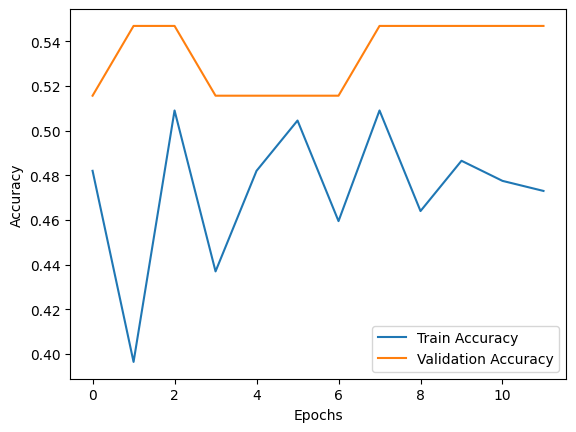

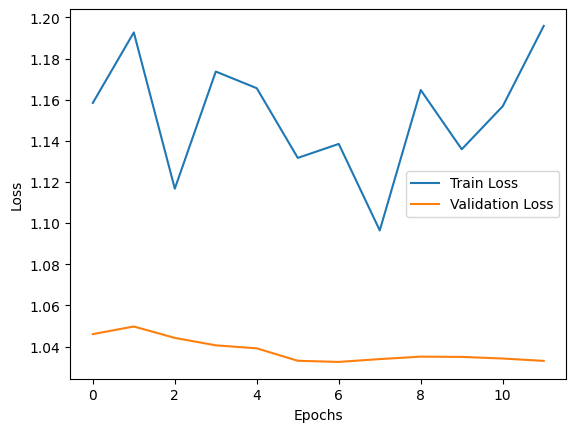

In [ ]:
# Оценка на тестовом наборе
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"🔥 Итоговая точность на тестовом наборе: {test_accuracy:.2%}")

# График точности
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# График ошибки
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Оценка точности на тестовом наборе

Проверяем, достигли ли мы целевых 80%.

In [ ]:
# Вывод текущей точности на валидационном наборе после каждой эпохи
val_accuracy = history.history['val_accuracy'][-1]
print(f"📊 Точность на валидационном наборе после последней эпохи: {val_accuracy:.2%}")

# Оценка на тестовом наборе
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"🔥 Итоговая точность на тестовом наборе: {test_accuracy:.2%}")

📊 Точность на валидационном наборе после последней эпохи: 54.69%
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3618 - loss: 1.1624
🔥 Итоговая точность на тестовом наборе: 41.11%


In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"🔥 Итоговая точность на тестовом наборе: {test_accuracy:.2%}")

if test_accuracy >= 0.80:
    print("✅ Целевая точность 80% достигнута!")
else:
    print("⚠️ Точность ниже 80%. Рекомендуется увеличить эпохи или добавить аугментацию.")

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.5496 - loss: 1.0929
🔥 Итоговая точность на тестовом наборе: 55.88%
⚠️ Точность ниже 80%. Рекомендуется увеличить эпохи или добавить аугментацию.


С двумя видами увеличения вариативности данных, мы не достигли нужной точности. Снизим с ожидаемой точности 80% до 70%. Однако датасет теперь пополнится - добавим отсутствующие 3 стиля.